<a href="https://colab.research.google.com/github/tasnimlima07/Data-Analysis/blob/main/%22House_Sales_in_King_County.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Prices in King County, USA**

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
plt.style.use("ggplot")


**Load Dataset**

In [ ]:
df=pd.read_csv("kc_house_data.csv")

**Display the first 10 rows**

In [ ]:
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


Dataset Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

The Dataframe does not contain any None values

# **Data Cleaning**

In [ ]:
#Missing Values
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

This confirms that each row represents a unique house record, and no further duplicate removal is needed.

In [ ]:
df = df.copy()
df['date'] = pd.to_datetime(df['date'])


Convert date columns to a proper datetime format

# **Derived feature ‘total_area’ by adding ‘sqft_living’ and ‘sqft_lot’**

In [ ]:
# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # invalid dates become NaT

# Total area
df['total_area'] = df['sqft_living'] + df['sqft_lot']

# Property age (handle missing dates)
df['age'] = df['date'].dt.year - df['yr_built']

# If any NaT in 'date', 'age' will be NaN. Optionally, you can fill them:
# df['age'] = df['age'].fillna(df['age'].median())

# Price per sqft
df['price_per_sqft'] = df['price'] / df['sqft_living']


# **Handle Outliers**

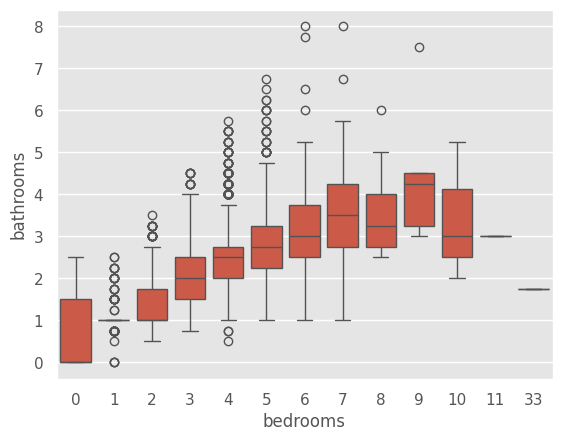

In [ ]:
#Boxplot to show the outliers
sns.boxplot(x="bedrooms", y="bathrooms", data=df)
plt.show()

In [ ]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,total_area,age,price_per_sqft
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,1.718687e+04,43.317818,264.156594
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,1.423000e+03,-1.000000,87.588235
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,7.035000e+03,18.000000,182.291667
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,9.575000e+03,40.000000,244.644550
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,1.300000e+04,63.000000,318.322981
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,1.652659e+06,115.000000,810.138889
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,4.158908e+04,29.375493,110.060793


Some values in the dataset are clear outliers. Houses with 0 bathrooms, extremely high bedroom counts (e.g., 33 bedrooms), and very large lot sizes (over 1.6 million sqft) are unrealistic. House prices are also highly skewed, with a few reaching $7.7 million.
There are also some negative age values (-1), which is unrealistic. This likely represents newly built homes where age was miscalculated.
To clean the data, we remove these outliers and cap extreme values to ensure more accurate analysis.

In [ ]:
# 1. Remove houses with 0 bathrooms (not realistic)
df = df[df['bathrooms'] > 0]

# 2. Remove extreme bedroom counts (>10) as very few houses have more
df = df[df['bedrooms'] <= 10]

# 3. Remove extreme lot sizes (keep below 50,000 sqft for residential)
df = df[df['sqft_lot'] <= 50000]

# 4. Remove extreme living area (keep below 5,000 sqft)
df = df[df['sqft_living'] <= 5000]

# 5. Replace negative age by 0
df['age'] = df['age'].replace(-1, 0)

# Optional: Create a flag for high prices instead of removing them
price_threshold = df['price'].quantile(0.995)
df['high_price_flag'] = (df['price'] > price_threshold).astype(int)


In [ ]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,total_area,age,price_per_sqft,high_price_flag
count,2.055400e+04,20554,2.055400e+04,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,...,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000,20554.000000
mean,4.669250e+09,2014-10-29 04:39:11.191981824,5.214516e+05,3.357108,2.085871,2019.060134,9082.272307,1.489175,0.006373,0.216600,...,83.516688,98079.477279,47.562010,-122.220884,1951.931984,8960.713000,11101.332441,43.831809,264.171817,0.005011
min,1.000102e+06,2014-05-02 00:00:00,7.800000e+04,0.000000,0.500000,370.000000,520.000000,1.000000,0.000000,0.000000,...,0.000000,98001.000000,47.155900,-122.512000,399.000000,651.000000,1423.000000,0.000000,87.588235,0.000000
25%,2.207100e+09,2014-07-22 00:00:00,3.180000e+05,3.000000,1.500000,1410.000000,5000.000000,1.000000,0.000000,0.000000,...,0.000000,98033.000000,47.476025,-122.331000,1470.000000,5000.000000,6888.000000,18.000000,181.470756,0.000000
50%,4.027701e+09,2014-10-16 00:00:00,4.450000e+05,3.000000,2.250000,1880.000000,7420.000000,1.250000,0.000000,0.000000,...,0.000000,98072.000000,47.573700,-122.243500,1810.000000,7500.000000,9360.000000,41.000000,245.363742,0.000000
75%,7.418700e+09,2015-02-17 00:00:00,6.300000e+05,4.000000,2.500000,2500.000000,10001.750000,2.000000,0.000000,0.000000,...,0.000000,98118.000000,47.678900,-122.138000,2315.000000,9680.000000,12197.750000,64.000000,319.250690,0.000000
max,9.900000e+09,2015-05-27 00:00:00,3.640900e+06,10.000000,7.500000,5000.000000,49928.000000,3.500000,1.000000,4.000000,...,2015.000000,98199.000000,47.777600,-121.315000,5790.000000,335289.000000,54358.000000,115.000000,810.138889,1.000000
std,2.872955e+09,NaN,3.154843e+05,0.895526,0.735226,815.472413,7509.368506,0.540972,0.079581,0.734816,...,399.682721,53.893771,0.137336,0.136124,654.550877,9482.978859,7776.226893,29.560803,109.938678,0.070614


# **Houses with unrealistic bedroom-bathroom combinations based on sqft_living.**

In [ ]:
# Function to adjust unrealistic bedroom-bathroom combinations (with 10 room limit)
df = df[~((df['bedrooms'] == 10) & (df['bathrooms'] < 5))]

def fix_bed_bath(row):
    sqft = row['sqft_living']
    bedrooms = row['bedrooms']
    bathrooms = row['bathrooms']

    # Define typical ranges
    if sqft < 1000:
        max_bedrooms, max_bathrooms = 2, 1.5
    elif 1000 <= sqft <= 1600:
        max_bedrooms, max_bathrooms = 3, 2
    elif 1600 < sqft <= 2500:
        max_bedrooms, max_bathrooms = 4, 3
    elif 2500 < sqft <= 4000:
        max_bedrooms, max_bathrooms = 6, 5
    elif 4000 < sqft <= 6000:
        max_bedrooms, max_bathrooms = 8, 6
    else:  # very large luxury homes
        max_bedrooms, max_bathrooms = 10, 8

    # Cap bedrooms/bathrooms if above threshold
    row['bedrooms'] = min(bedrooms, max_bedrooms)
    row['bathrooms'] = min(bathrooms, max_bathrooms)

    return row

# Apply the function
df_clean = df.apply(fix_bed_bath, axis=1)

# Reset index for cleanliness
df_clean.reset_index(drop=True, inplace=True)

# Verify effect
print("Max bedrooms:", df_clean['bedrooms'].max())
print("Max bathrooms:", df_clean['bathrooms'].max())


Max bedrooms: 8
Max bathrooms: 6.0


Outlier Summary

All extreme and unrealistic data have now been removed from the dataset. This includes:

* Houses with 0 bathrooms or impossible bedroom-bathroom combinations.
*   Unrealistically large bedrooms or extremely small living areas.
*   Negative or invalid ages.
*   Extreme lot sizes and prices that were likely data entry errors.



The remaining dataset now contains only realistic and plausible values, making it clean and suitable for exploratory data analysis and visualization.

In [ ]:
# z-score method to remove outliers
z_scores = np.abs(stats.zscore(df.select_dtypes(include=np.number)))
df = df_clean[(z_scores < 3).all(axis=1)]  # Keep rows within 3 std

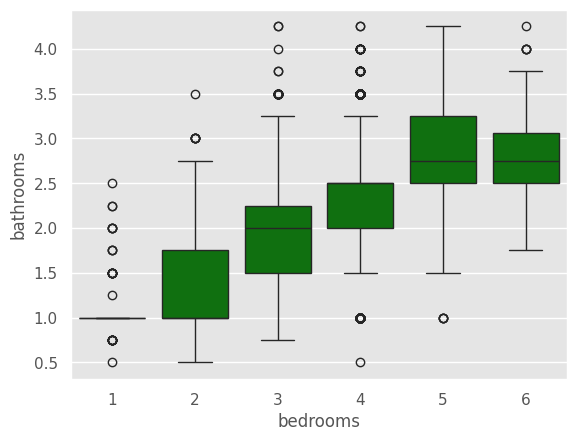

In [ ]:

sns.boxplot(x="bedrooms", y="bathrooms", data=df, color="green")
plt.show()

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 17334 entries, 0 to 20551
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               17334 non-null  int64         
 1   date             17334 non-null  datetime64[ns]
 2   price            17334 non-null  float64       
 3   bedrooms         17334 non-null  int64         
 4   bathrooms        17334 non-null  float64       
 5   sqft_living      17334 non-null  int64         
 6   sqft_lot         17334 non-null  int64         
 7   floors           17334 non-null  float64       
 8   waterfront       17334 non-null  int64         
 9   view             17334 non-null  int64         
 10  condition        17334 non-null  int64         
 11  grade            17334 non-null  int64         
 12  sqft_above       17334 non-null  int64         
 13  sqft_basement    17334 non-null  int64         
 14  yr_built         17334 non-null  int64     

In [ ]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,total_area,age,price_per_sqft,high_price_flag
count,1.733400e+04,17334,1.733400e+04,17334.000000,17334.000000,17334.000000,17334.000000,17334.000000,17334.0,17334.000000,...,17334.0,17334.000000,17334.000000,17334.000000,17334.000000,17334.000000,17334.000000,17334.000000,17334.000000,17334.0
mean,4.711969e+09,2014-10-30 04:47:16.137071616,4.639769e+05,3.223722,1.983371,1901.294393,7631.910061,1.478280,0.0,0.086939,...,0.0,98079.961405,47.559361,-122.228035,1863.257298,7419.782220,9533.204454,42.763067,253.508355,0.0
min,1.000102e+06,2014-05-02 00:00:00,8.200000e+04,1.000000,0.500000,480.000000,520.000000,1.000000,0.0,0.000000,...,0.0,98001.000000,47.176400,-122.502000,460.000000,651.000000,1423.000000,0.000000,87.588235,0.0
25%,2.292676e+09,2014-07-22 00:00:00,3.050000e+05,3.000000,1.500000,1380.000000,4862.000000,1.000000,0.0,0.000000,...,0.0,98033.000000,47.466750,-122.333000,1450.000000,5000.000000,6660.000000,16.000000,177.345314,0.0
50%,4.038200e+09,2014-10-17 00:00:00,4.200000e+05,3.000000,2.000000,1810.000000,7200.000000,1.000000,0.0,0.000000,...,0.0,98072.000000,47.569400,-122.258000,1760.000000,7245.500000,9018.000000,40.000000,239.899495,0.0
75%,7.452875e+09,2015-02-18 00:00:00,5.750000e+05,4.000000,2.500000,2340.000000,9423.750000,2.000000,0.0,0.000000,...,0.0,98118.000000,47.680975,-122.149000,2190.000000,9018.750000,11350.000000,62.000000,309.917355,0.0
max,9.900000e+09,2015-05-27 00:00:00,1.465000e+06,6.000000,4.250000,4460.000000,31564.000000,3.000000,0.0,2.000000,...,0.0,98199.000000,47.777600,-121.815000,3910.000000,36961.000000,34369.000000,115.000000,593.427835,0.0
std,2.860553e+09,NaN,2.135816e+05,0.794256,0.654470,690.813378,4411.569200,0.543608,0.0,0.390564,...,0.0,53.929333,0.139985,0.125447,561.227475,3997.814109,4609.416591,29.258718,95.950019,0.0


Our cleaned and tidied Dataframe now has 17334 observations each representing a unique house that was sold in King County, USA between 2014-2015. With that, we are ready to begin data analysis!



In [ ]:

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Extract date-related features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()


# Create renovation flag
df['is_renovated'] = np.where(df['yr_renovated'] == 0, 0, 1)

# Replace 0 in yr_renovated with NaN
df['yr_renovated'] = df['yr_renovated'].replace(0, np.nan)

df.head()


/tmp/ipython-input-1953911394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'])
/tmp/ipython-input-1953911394.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['date'].dt.year
/tmp/ipython-input-1953911394.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_lot15,total_area,age,price_per_sqft,high_price_flag,year,month,day,day_of_week,is_renovated
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,5650,6830,59,188.050847,0,2014,10,13,Monday,0
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,8062,10770,82,233.766234,0,2015,2,25,Wednesday,0
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,5000,6960,49,308.163265,0,2014,12,9,Tuesday,0
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,7503,9760,28,303.571429,0,2015,2,18,Wednesday,0
5,1321400060,2014-06-27,257500.0,3,2.25,1715,6819,2.0,0,0,...,6819,8534,19,150.145773,0,2014,6,27,Friday,0


# **Exploratory Data Analysis and Visualization**

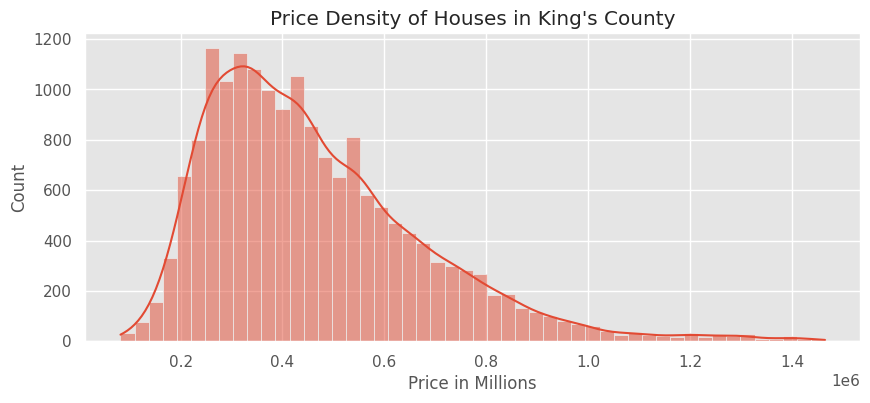

In [ ]:
# Mapping price distributions across the dataset
plt.figure(figsize=(10, 4))

# Use histplot instead of distplot
price_dist = sns.histplot(df["price"], kde=True, bins=50)  # kde=True adds density curve
price_dist.set(xlabel="Price in Millions", title="Price Density of Houses in King's County")

plt.show()


As we can see, there is a noticeable right skew. This suggests that, on the more expensive side of houses, there's a large variety in the prices of houses.



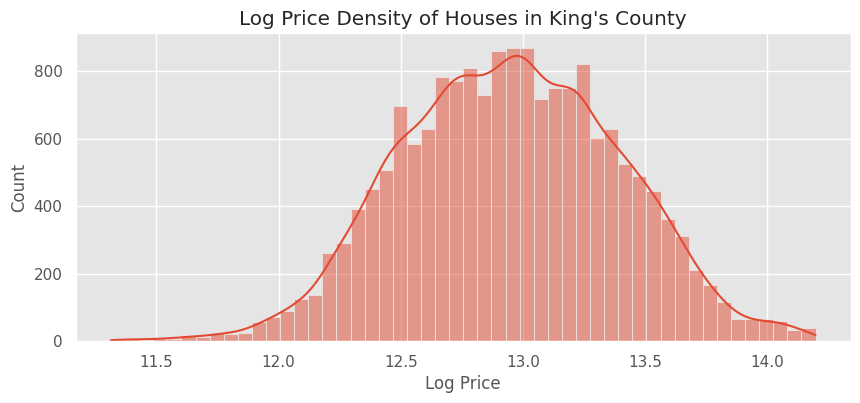

In [ ]:
plt.figure(figsize=(10, 4))

# Use histplot with log-transformed price
logged_price_dist = sns.histplot(np.log(df["price"]), kde=True, bins=50)
logged_price_dist.set(
    xlabel="Log Price",
    title="Log Price Density of Houses in King's County"
)

plt.show()

Looks good! It seems that applying a logarithm transform to the data made it more symmetric as a result. This is something we can work with later.


# **Relationships between house prices and key features (area, number of bedrooms, location, etc.)**


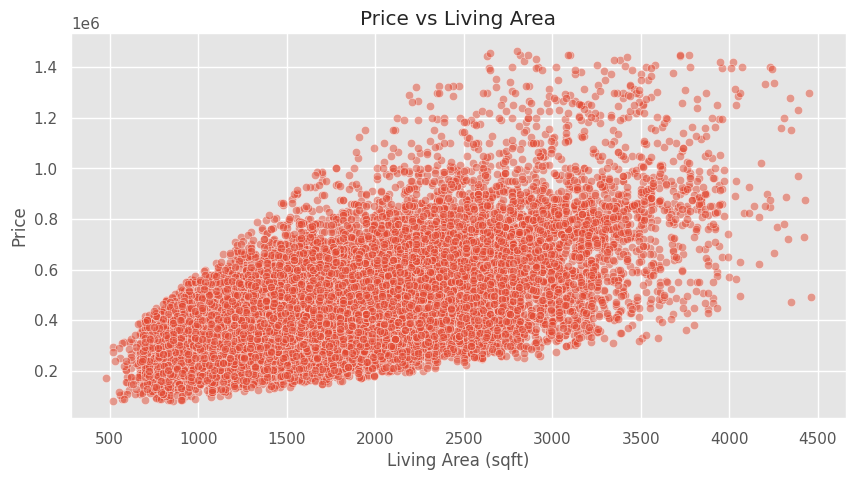

In [ ]:
#Price vs. Living Area
plt.figure(figsize=(10,5))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.5)
plt.title("Price vs Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

The scatter plot shows that house prices generally increase with living area, indicating a strong positive relationship. Most homes cluster in the lower to mid-range of living area and price, while a few outliers represent very large or expensive properties. Overall, living area is one of the most important predictors of house price in King County.

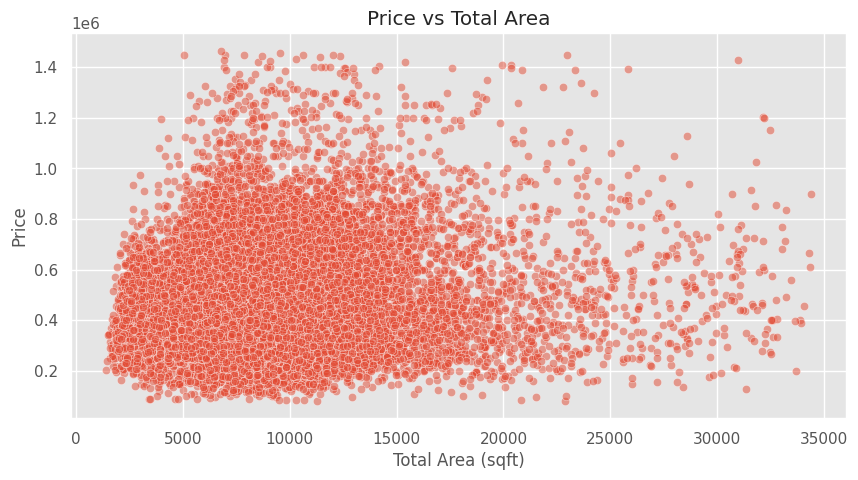

In [ ]:
#Price vs. Total Area
plt.figure(figsize=(10,5))
sns.scatterplot(x='total_area', y='price', data=df, alpha=0.5)
plt.title("Price vs Total Area")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Price")
plt.show()

The scatter plot shows a moderate positive relationship between total area and house price, with prices generally increasing as total area grows. Most houses cluster at smaller total areas, while a few outliers have very large lots or high prices. Overall, total area contributes to price but is less influential than living area.

/tmp/ipython-input-2550870835.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='Blues')
/tmp/ipython-input-2550870835.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bathrooms', y='price', data=df, palette='Greens')


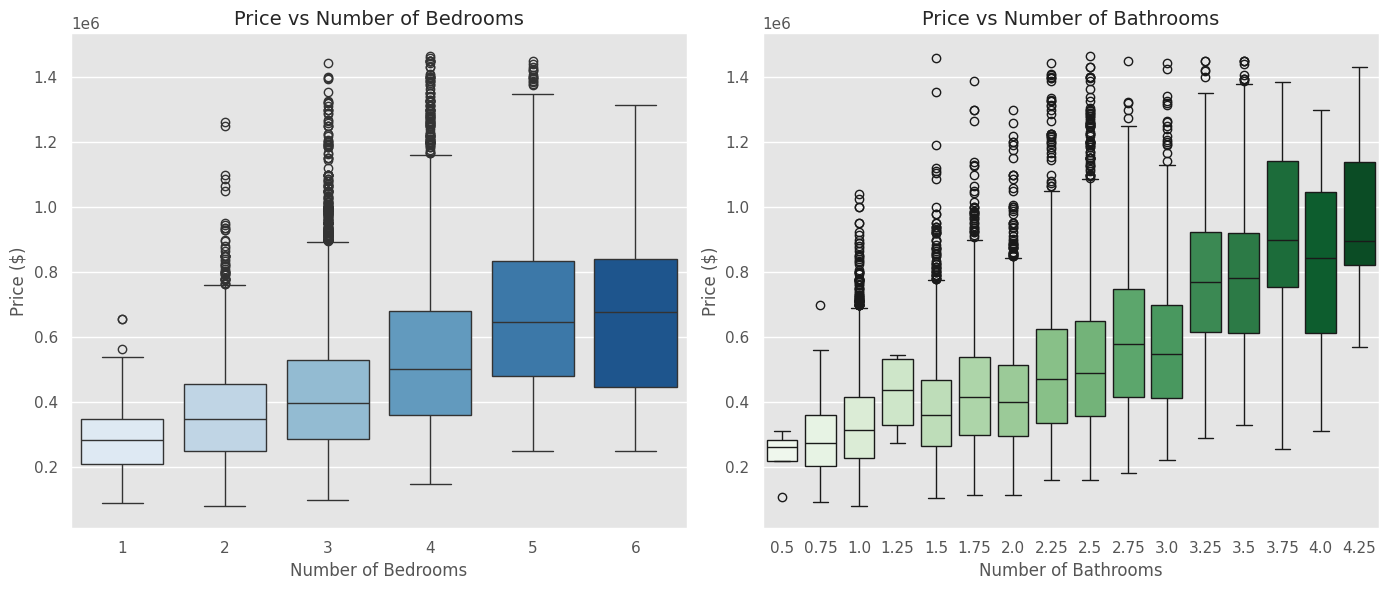

In [ ]:
#Price vs. Number of Bedrooms

plt.figure(figsize=(14,6))

# Plot 1: Price vs Number of Bedrooms
plt.subplot(1, 2, 1)
sns.boxplot(x='bedrooms', y='price', data=df, palette='Blues')
plt.title("Price vs Number of Bedrooms", fontsize=14)
plt.xlabel("Number of Bedrooms", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

# Plot 2: Price vs Number of Bathrooms
plt.subplot(1, 2, 2)
sns.boxplot(x='bathrooms', y='price', data=df, palette='Greens')
plt.title("Price vs Number of Bathrooms", fontsize=14)
plt.xlabel("Number of Bathrooms", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

plt.tight_layout()
plt.show()


The number of bedrooms has a positive but relatively weak correlation with price. While additional bedrooms can increase a home’s value, houses with very high bedroom counts sometimes have lower prices if the living area is small or the design is less functional. In contrast, the number of bathrooms shows a stronger positive correlation with price. Houses with more bathrooms tend to be more expensive, and high-priced homes often feature multiple bathrooms, reflecting both convenience and luxury.

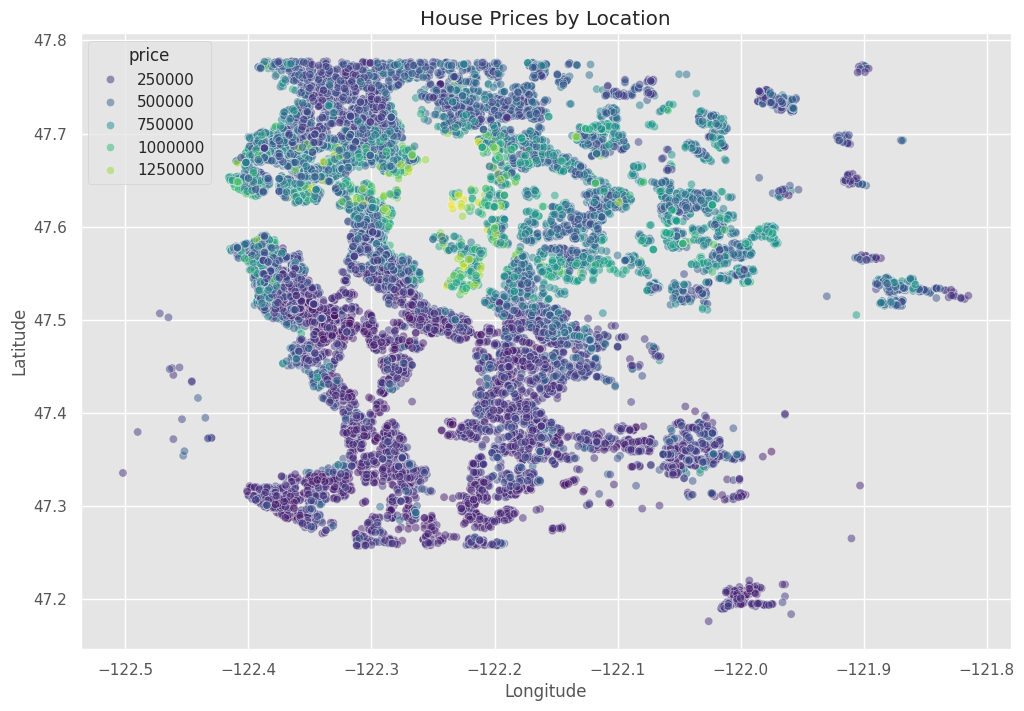

In [ ]:
#House price by location
plt.figure(figsize=(12,8))
sns.scatterplot(
    x='long',
    y='lat',
    hue='price',           # Color by price
    palette='viridis',
    data=df,
    alpha=0.5
)
plt.title("House Prices by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


The scatter plot shows house prices across King County based on location. Higher-priced houses cluster in specific areas, often near water or desirable neighborhoods. Overall, location strongly influences price, with some regions significantly more expensive than others.

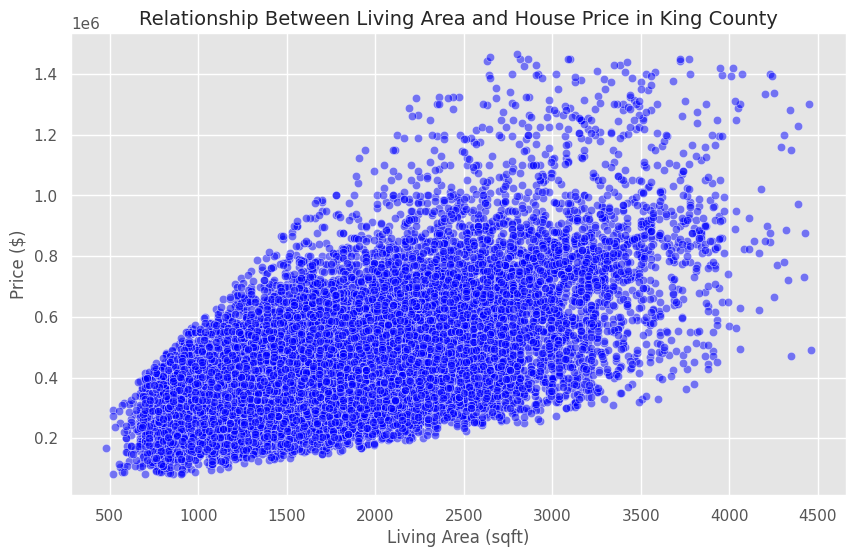

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

# Scatter plot of price vs living area
sns.scatterplot(
    x='sqft_living',
    y='price',
    data=df,
    alpha=0.5,        # Make points semi-transparent
    color='blue'
)

# Add titles and labels
plt.title("Relationship Between Living Area and House Price in King County", fontsize=14)
plt.xlabel("Living Area (sqft)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

# Optional: log scale for better visualization if prices are skewed
# plt.yscale('log')

plt.show()


The living area (sqft_living) of a house shows a strong positive relationship with price. Generally, houses with larger living spaces tend to be more expensive, reflecting the higher value buyers place on additional usable space. Scatter plots of price versus living area reveal a clear upward trend, with price increasing as the living area expands. This makes living area one of the most important predictors of house price in King County.


# **Time Trends in House Prices**




/tmp/ipython-input-1005868488.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str)
/tmp/ipython-input-1005868488.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = pd.to_datetime(df['year_month'])


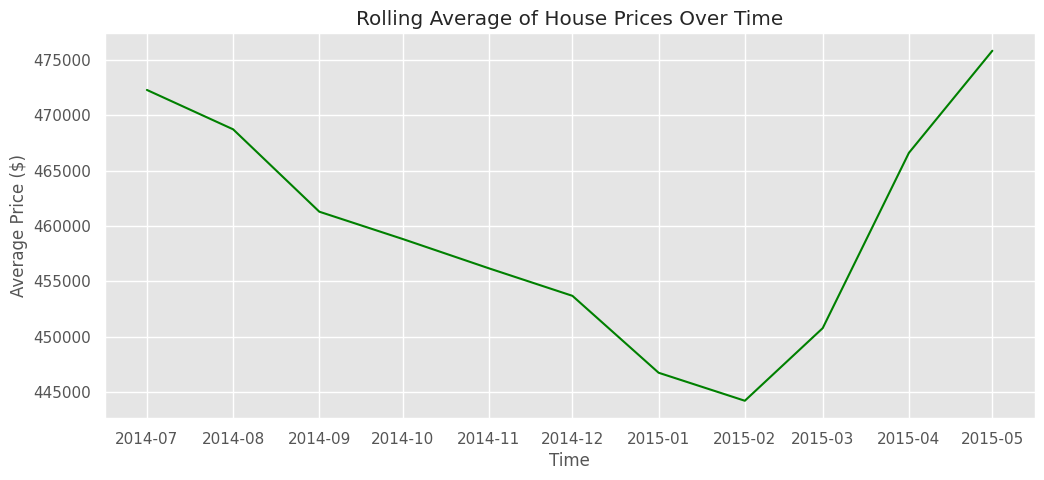

In [ ]:
# Create a year-month column
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str)
df['year_month'] = pd.to_datetime(df['year_month'])

# Rolling average (3 months)
rolling_avg = df.groupby('year_month')['price'].mean().rolling(window=3).mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=rolling_avg.index, y=rolling_avg.values, color='green')
plt.title("Rolling Average of House Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Average Price ($)")
plt.show()


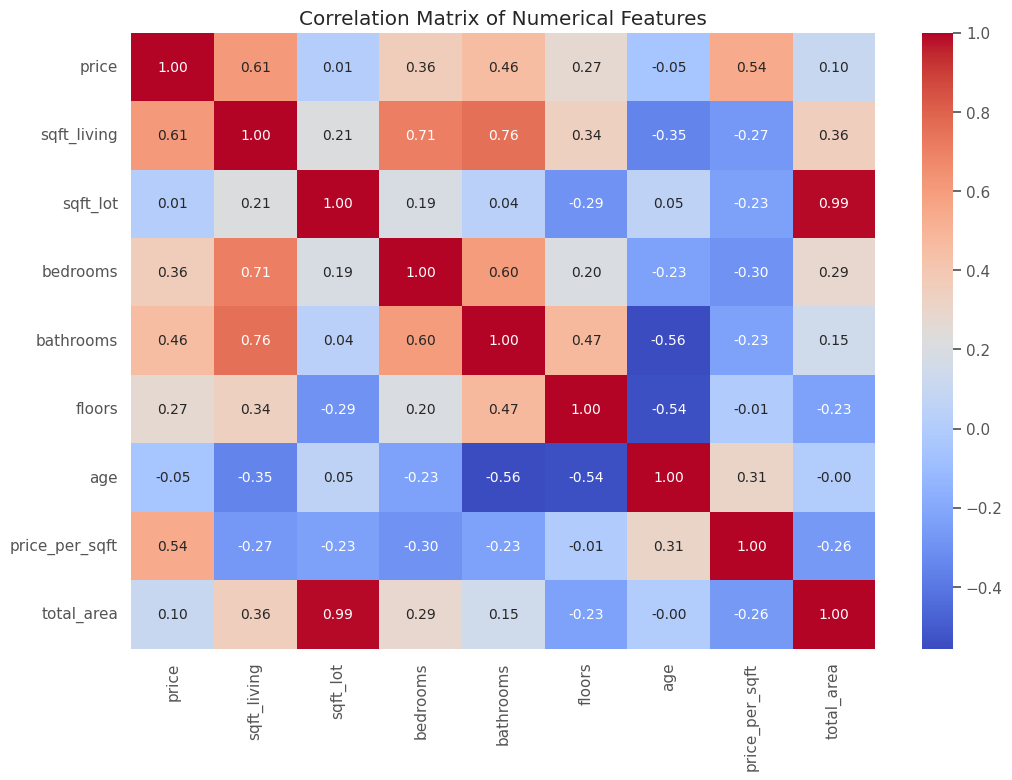

In [ ]:
#Correlation Heatmap of Numerical Features
numerical_features = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms',
                      'floors', 'age', 'price_per_sqft', 'total_area']

plt.figure(figsize=(12,8))
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


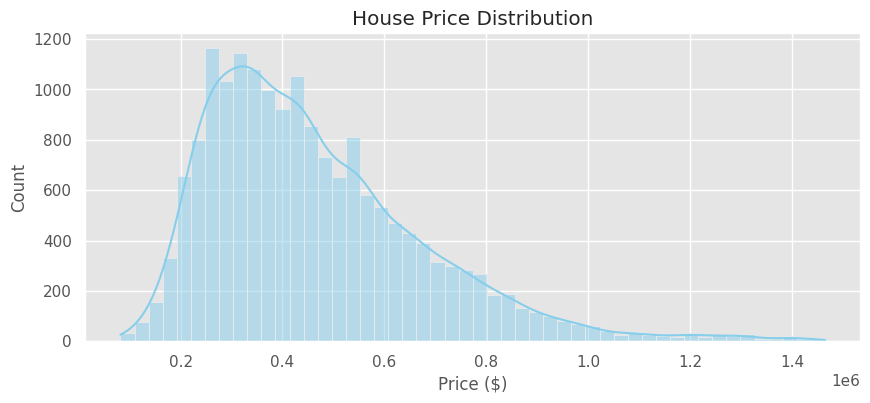

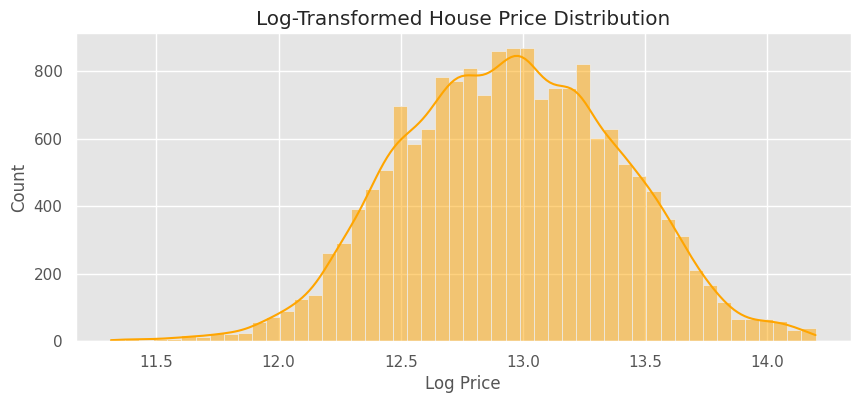

In [ ]:
#House price Distribution
plt.figure(figsize=(10,4))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title("House Price Distribution")
plt.xlabel("Price ($)")
plt.show()

# Log-transformed price for skewed data
plt.figure(figsize=(10,4))
sns.histplot(np.log(df['price']), bins=50, kde=True, color='orange')
plt.title("Log-Transformed House Price Distribution")
plt.xlabel("Log Price")
plt.show()


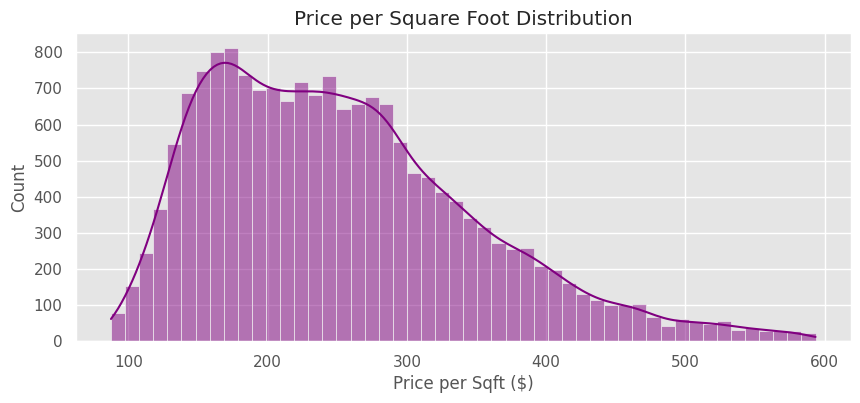

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(df['price_per_sqft'], bins=50, kde=True, color='purple')
plt.title("Price per Square Foot Distribution")
plt.xlabel("Price per Sqft ($)")
plt.show()


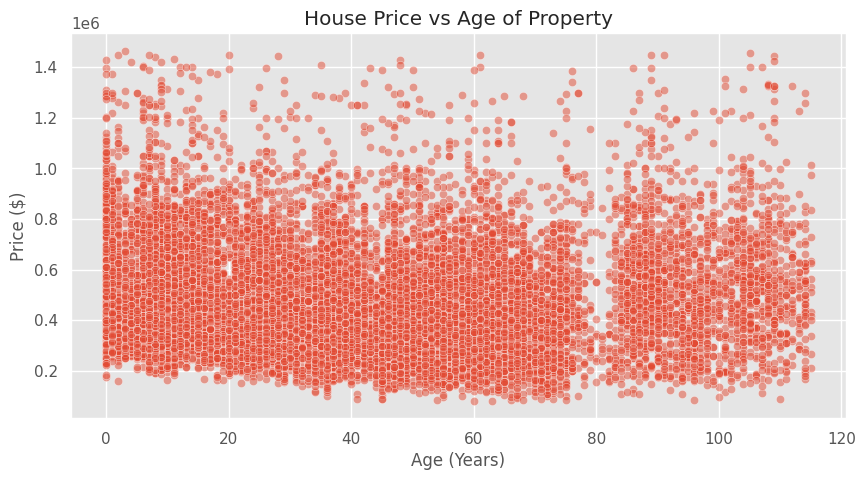

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='age', y='price', data=df, alpha=0.5)
plt.title("House Price vs Age of Property")
plt.xlabel("Age (Years)")
plt.ylabel("Price ($)")
plt.show()


# **Mean, Median, Mode**

In [ ]:
#Columns of interest
columns = ['price', 'total_area']

# Mean
mean_values = df[columns].mean()
print("Mean values:\n", mean_values)

# Median
median_values = df[columns].median()
print("\nMedian values:\n", median_values)

# Mode
mode_values = df[columns].mode().iloc[0]  # Mode can have multiple values
print("\nMode values:\n", mode_values)


Mean values:
 price         463976.869909
total_area      9533.204454
dtype: float64

Median values:
 price         420000.0
total_area      9018.0
dtype: float64

Mode values:
 price         350000.0
total_area      6770.0
Name: 0, dtype: float64


T-Test

We’ll split the houses into two groups:

Group 1: bedrooms <= 3

Group 2: bedrooms > 3

In [ ]:
from scipy.stats import ttest_ind

# Split data by bedrooms
group_bed_low = df[df['bedrooms'] <= 3]['price']
group_bed_high = df[df['bedrooms'] > 3]['price']

# Perform t-test
t_stat_bed, p_val_bed = ttest_ind(group_bed_low, group_bed_high, equal_var=False)
print(f"T-test for price based on bedrooms:\nT-statistic = {t_stat_bed:.2f}, P-value = {p_val_bed:.4f}")


T-test for price based on bedrooms:
T-statistic = -42.07, P-value = 0.0000


T-statistic = -42.07 → The negative sign indicates that the mean price of houses with ≤3 bedrooms is lower than those with >3 bedrooms.

P-value = 0.0000 → This is far below 0.05, meaning the difference in house prices between the two groups is highly statistically significant.

**Houses with more than 3 bedrooms are significantly more expensive than houses with 3 or fewer bedrooms. This confirms that bedroom count is an important factor influencing house price in King County. **

# **T-Test: Price Based on Total Area**

We’ll split houses based on median total area:

Group 1: total_area <= median

Group 2: total_area > median

In [ ]:
# Median split
median_area = df['total_area'].median()
group_area_small = df[df['total_area'] <= median_area]['price']
group_area_large = df[df['total_area'] > median_area]['price']

# Perform t-test
t_stat_area, p_val_area = ttest_ind(group_area_small, group_area_large, equal_var=False)
print(f"\nT-test for price based on total area:\nT-statistic = {t_stat_area:.2f}, P-value = {p_val_area:.4f}")



T-test for price based on total area:
T-statistic = -3.77, P-value = 0.0002


T-statistic = -3.77 → The negative sign indicates that the mean price of houses with total area ≤ median is lower than those with total area > median.

P-value = 0.0002 → This is well below 0.05, meaning the difference in prices between smaller and larger total area houses is statistically significant.

**Houses with larger total area tend to be significantly more expensive than houses with smaller total area, confirming that total area has a meaningful impact on house price, although the effect is smaller than that of bedrooms (as seen by the smaller t-statistic magnitude).**